# ***IMPORTING LIBRARIES***

In [1]:
%%time

import os, random
import numpy as np
import pandas as pd
from PIL import Image
import imghdr
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report
import tensorflow as tf
from tensorflow.keras.models import Model, Sequential, load_model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Flatten, Dropout, BatchNormalization,Conv2D, MaxPooling2D
from tensorflow.keras.applications import ResNet50, VGG16, InceptionV3, ResNet101, ResNet152V2
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import backend as K

# Importing warnings
import warnings
warnings.filterwarnings('ignore')

CPU times: total: 11.1 s
Wall time: 16.3 s


# **CLEAR SESSION**

In [2]:
# Clear session to free up resources
K.clear_session()

# **REMOVING FILES OTHER THAN IMAGES**

In [3]:
%%time

image_types= ['jpeg','png', 'jpg']
for root, dirs, files in os.walk('C:/Users/Lenovo/CLDD/thesis Code/Cotton'):
    for file in files:
        file_path = os.path.join(root, file)
        image_type = imghdr.what(file_path)
        if image_type not in image_types:
            print('File name : '.format(file, image_type))
        else:
            cv2.imread(file_path)

CPU times: total: 12.4 s
Wall time: 14.2 s


# **LOAD TOTAL IMAGES**

In [3]:

# Define valid image types (case-sensitive for Pillow)
image_types = ['JPEG', 'PNG', 'JPG']  # Updated to match Pillow's format

# Function to check image type using Pillow
def identify_image_type(image_path):
    try:
        with Image.open(image_path) as img:
            return img.format  # Returns 'JPEG', 'PNG', etc.
    except IOError:
        return None  # Return None if the file is not a valid image

# Initialize counters
loaded_count = 0
failed_count = 0
invalid_count = 0

# Walk through the directory and check each file
for root, dirs, files in os.walk('C:/Users/Lenovo/CLDD/thesis Code/Cotton'):
    for file in files:
        file_path = os.path.join(root, file)
        
        # Get the image type using Pillow
        image_type = identify_image_type(file_path)
        
        # If the image type is not in the allowed types, count as invalid
        if image_type not in image_types:
            invalid_count += 1
        else:
            # Try to read the image with OpenCV
            image = cv2.imread(file_path)
            
            if image is None:
                failed_count += 1  # Count as failed if OpenCV cannot load the image
            else:
                loaded_count += 1  # Count as successfully loaded

# Print summary at the end
print(f'Total images loaded successfully: {loaded_count}')
print(f'Total images failed to load: {failed_count}')
print(f'Total invalid file types: {invalid_count}')

Total images loaded successfully: 1687
Total images failed to load: 0
Total invalid file types: 0


In [4]:
# Define valid image types
image_types = ['JPEG', 'PNG', 'JPG']  # Updated to match Pillow's format

# Function to check image type using Pillow
def identify_image_type(image_path):
    try:
        with Image.open(image_path) as img:
            return img.format  # Returns 'JPEG', 'PNG', etc.
    except IOError:
        return None  # Return None if the file is not a valid image

# Walk through the directory and check each file
for root, dirs, files in os.walk('C:/Users/Lenovo/CLDD/thesis Code/Cotton'):
    for file in files:
        file_path = os.path.join(root, file)
        
        # Get the image type using Pillow
        image_type = identify_image_type(file_path)
        
        # If the image type is not in the allowed types, print the file name
        if image_type not in image_types:
            print(f'Invalid file type: {file} ({image_type})')
        else:
            # Try to read the image with OpenCV
            image = cv2.imread(file_path)
            if image is None:
                print(f'Failed to load image: {file}')
            else:
                print(f'Successfully loaded: {file}')

Successfully loaded: 2015-angular-leaf-spot-colquitt-county-2.jpg
Successfully loaded: bact102.jpg
Successfully loaded: bact106.jpg
Successfully loaded: bact107.jpg
Successfully loaded: bact109.jpg
Successfully loaded: bact11.jpg
Successfully loaded: bact110.jpg
Successfully loaded: bact111.jpg
Successfully loaded: bact112.jpg
Successfully loaded: bact113.jpg
Successfully loaded: bact114.jpg
Successfully loaded: bact119.jpg
Successfully loaded: bact128.jpg
Successfully loaded: bact143.png
Successfully loaded: bact146.png
Successfully loaded: bact149.png
Successfully loaded: bact154.jpg
Successfully loaded: bact158.jpg
Successfully loaded: bact16.jpg
Successfully loaded: bact169.jpg
Successfully loaded: bact172.jpg
Successfully loaded: bact179.png
Successfully loaded: bact190.png
Successfully loaded: bact199.jpg
Successfully loaded: bact202.png
Successfully loaded: bact207.png
Successfully loaded: bact210.jpg
Successfully loaded: bact22.jpg
Successfully loaded: bact222.jpg
Successfully 

# **CHECKING IMAGES OF 5 CLASSES**

CPU times: total: 375 ms
Wall time: 408 ms


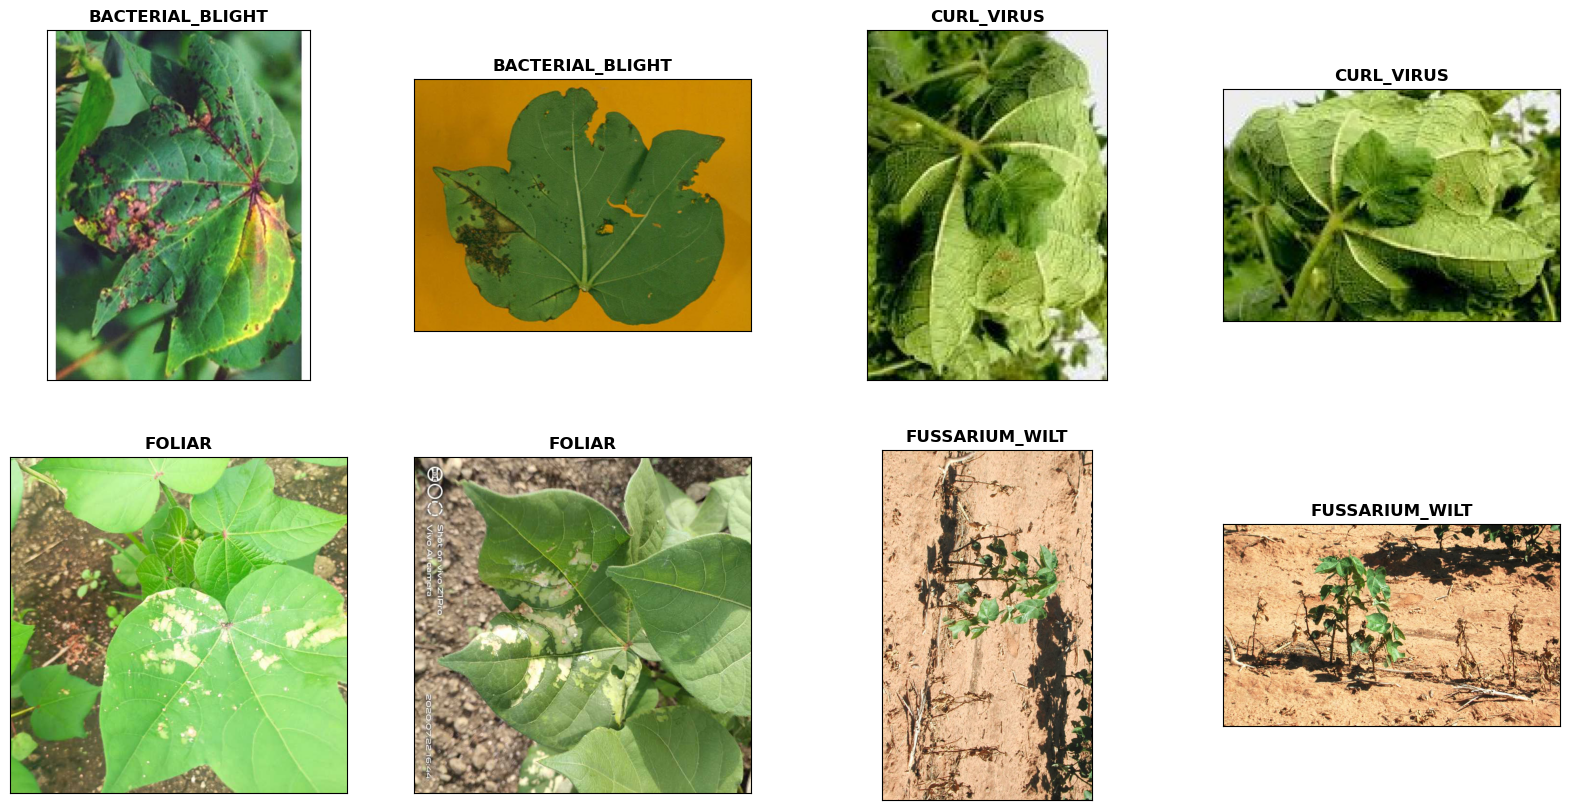

In [4]:
%%time
fig, axes = plt.subplots(2,4, figsize=(20,10))
ax = axes.ravel()
i=0
path = 'C:/Users/Lenovo/CLDD/thesis Code/Cotton/train'
for folder in os.listdir(path):
    folder_path = os.path.join(path, folder)
    image = os.listdir(folder_path)
    selected_img = random.sample(image,2)

    for image in selected_img:
        if i >= len(ax):  # Prevent IndexError
            break
        img_path = os.path.join(folder_path, image)
        img = plt.imread(img_path)
        ax[i].set_title(folder.upper(),fontweight='bold')
        ax[i].imshow(img)
        ax[i].set_xticks([])
        ax[i].set_yticks([])
        i=i+1

# **QUANTITY OF IMAGES IN EACH TRAIN DIRECTORY**

Number of Images in bacterial_blight: 288
Number of Images in curl_virus: 241
Number of Images in foliar: 72
Number of Images in fussarium_wilt: 192
Number of Images in healthy: 319


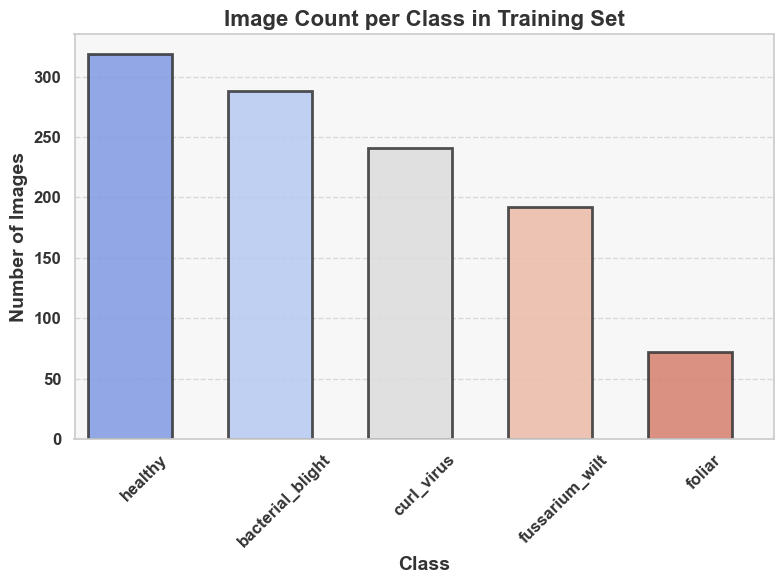

CPU times: total: 484 ms
Wall time: 599 ms


In [5]:
%%time

# Seaborn theme with custom background and grid
sns.set_theme(style="whitegrid", rc={'axes.facecolor':'#f7f7f7', 'figure.facecolor':'#ffffff'})

# Function to count images in each folder
def images_count(path, name):
    count = {}
    for folder in os.listdir(path):
        folder_path = os.path.join(path, folder)
        if os.path.isdir(folder_path):
            count[folder] = len(os.listdir(folder_path))
            print(f'\033[1mNumber of Images in {folder}: {count[folder]}\033[0m')
    # Create DataFrame and prepare it for plotting
    df = pd.DataFrame(count, index=[name]).melt(var_name='class').sort_values(by='value', ascending=False)
    return df

# Get the image count DataFrame
class_count = images_count('C:/Users/Lenovo/CLDD/thesis Code/Cotton/train', 'train')

# Create the barplot with a color palette
fig, ax = plt.subplots(figsize=(8, 6))
sns.barplot(data=class_count, x='class', y='value', ax=ax, edgecolor='#333333', linewidth=2, palette="coolwarm", alpha=0.85)

# Manually adjust the width of the bars
for bar in ax.patches:
    bar.set_width(0.6)

# Customize axis labels, title, and ticks
ax.set_xlabel('Class', fontsize=14, weight='bold', color='#333333')
ax.set_ylabel('Number of Images', fontsize=14, weight='bold', color='#333333')
ax.set_title('Image Count per Class in Training Set', fontsize=16, weight='bold', color='#333333')

# Customize ticks
plt.xticks(rotation=45, fontsize=12, weight='bold', color='#333333')
plt.yticks(fontsize=12, weight='bold', color='#333333')

# Add gridlines with customization
ax.grid(True, which='major', axis='y', linestyle='--', alpha=0.7)

# Adjust layout to avoid overlap
plt.tight_layout()

#Number of images per Class
#plt.savefig('D:/thesis Code/Model/Number_of_Images_per_Class.jpg',dpi=500)

# Show the plot
plt.show()

# **DATA AUGMENTATION**

In [6]:
%%time

train_gen = ImageDataGenerator(rescale=1./255, rotation_range=20, shear_range=0.2,zoom_range=0.5,
                                fill_mode='nearest', horizontal_flip=True, width_shift_range=0.2)
train_generator = train_gen.flow_from_directory('C:/Users/Lenovo/CLDD/thesis Code/Cotton/train', target_size=(224,224), batch_size=32,
                                              color_mode='rgb', class_mode='categorical')

Found 1112 images belonging to 5 classes.
CPU times: total: 141 ms
Wall time: 226 ms


In [7]:
# Total no of samples in training set
train_generator.classes.shape

# Computing class weights using scikit-learn library's function compute_class_weight
classes = train_generator.classes    # Array of original class labels per sample
weights = compute_class_weight(class_weight='balanced', classes=np.unique(classes),y=classes)

# Weights Dictionary
weight_dict = dict(enumerate(weights))
weight_dict

{0: 0.7722222222222223,
 1: 0.9228215767634855,
 2: 3.088888888888889,
 3: 1.1583333333333334,
 4: 0.69717868338558}

In [8]:
%%time

val_gen = ImageDataGenerator(rescale=1./255)

validation_generator = val_gen.flow_from_directory('C:/Users/Lenovo/CLDD/thesis Code/Cotton/val', target_size=(224,224), batch_size=32,
                                              color_mode='rgb', class_mode='categorical')

test_generator =  val_gen.flow_from_directory('C:/Users/Lenovo/CLDD/thesis Code/Cotton/test', target_size=(224,224), batch_size=32,
                                              color_mode='rgb', class_mode='categorical')

Found 294 images belonging to 5 classes.
Found 281 images belonging to 5 classes.
CPU times: total: 46.9 ms
Wall time: 155 ms


# **TRAINING CNN MODEL ARCHITECTURE USING KERAS**

In [9]:
# Define the CNN model architecture
model3 = Sequential()
model3.add(Conv2D(32, (3, 3), activation='relu', input_shape=(224, 224, 3)))
model3.add(BatchNormalization())  # Add BatchNorm
model3.add(MaxPooling2D((2, 2)))

model3.add(Conv2D(64, (3, 3), activation='relu'))
model3.add(BatchNormalization())  # Add BatchNorm
model3.add(MaxPooling2D((2, 2)))

model3.add(Conv2D(128, (3, 3), activation='relu'))
model3.add(BatchNormalization())  # Add BatchNorm
model3.add(MaxPooling2D((2, 2)))

model3.add(Flatten())
model3.add(Dense(128, activation='relu'))
model3.add(Dropout(0.2))  # Dropout to prevent overfitting
model3.add(Dense(5, activation='softmax'))  # Output layer

# Predictions
#predictions3 = Dense(5, activation='softmax')(x)



# **COMPILING CNN MODEL**

In [10]:
model3.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
callbacks = EarlyStopping(monitor='val_accuracy', patience=100, verbose=1,
                            mode='max', restore_best_weights=True)
# Callbacks
#early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
#model_checkpoint = ModelCheckpoint('D:/thesis Code/Model/CNN_best_model.keras', save_best_only=True)

# **FITTING CNN MODEL**

In [11]:
# Train the model
history3 = model3.fit(train_generator, validation_data=validation_generator, epochs=80, callbacks=[callbacks], verbose=1, class_weight=weight_dict)
                    #callbacks=[early_stopping, model_checkpoint])


Epoch 1/80
35/35 [==============================] - 92s 3s/step - loss: 10.5987 - accuracy: 0.4487 - val_loss: 30.1563 - val_accuracy: 0.1633
Epoch 2/80
35/35 [==============================] - 81s 2s/step - loss: 2.5885 - accuracy: 0.4964 - val_loss: 26.6246 - val_accuracy: 0.1565
Epoch 3/80
35/35 [==============================] - 81s 2s/step - loss: 1.5759 - accuracy: 0.4496 - val_loss: 15.5193 - val_accuracy: 0.2041
Epoch 4/80
35/35 [==============================] - 80s 2s/step - loss: 1.4855 - accuracy: 0.4883 - val_loss: 23.7890 - val_accuracy: 0.2109
Epoch 5/80
35/35 [==============================] - 80s 2s/step - loss: 1.4979 - accuracy: 0.5072 - val_loss: 29.7298 - val_accuracy: 0.1259
Epoch 6/80
35/35 [==============================] - 82s 2s/step - loss: 1.3964 - accuracy: 0.4209 - val_loss: 12.6359 - val_accuracy: 0.1939
Epoch 7/80
35/35 [==============================] - 81s 2s/step - loss: 1.2450 - accuracy: 0.5081 - val_loss: 2.9832 - val_accuracy: 0.3197
Epoch 8/80
35

# **SAVE CNN IN HD5 OR KERAS FORMAT**

In [12]:
model3.save('D:/thesis Code/Model/CLDD_CNN_AC70_EP80.h5')

# **CNN MODEL LOAD**

In [13]:
model3 = load_model('D:/thesis Code/Model/CLDD_CNN_AC70_EP80.h5')

# **EVALUATION CNN**

In [14]:
val_loss, val_acc = model3.evaluate(validation_generator)
print(f'\033[1mValidation Accuracy: {val_acc * 100:.2f}%\033[0m')

# Evaluate on the test set
test_loss, test_acc = model3.evaluate(test_generator)
print(f'\033[1mTest Accuracy: {test_acc * 100:.2f}%\033[0m')

10/10 [==============================] - 5s 425ms/step - loss: 0.1705 - accuracy: 0.9490
Validation Accuracy: 94.90%
9/9 [==============================] - 4s 444ms/step - loss: 0.3488 - accuracy: 0.9075
Test Accuracy: 90.75%


# **CNN MODEL PREDICTION**

In [16]:
# Make predictions on the test set
predictions = model3.predict(test_generator)

# Convert predictions to class labels
y_pred = np.argmax(predictions, axis=1)
y_true = test_generator.classes
class_labels = list(test_generator.class_indices.keys())

# Print the predictions
print("Predicted labels:", y_pred)
print("True labels:", y_true)
print("Class labels:", class_labels)

9/9 [==============================] - 4s 454ms/step
Predicted labels: [1 0 2 1 2 3 3 2 1 2 2 2 1 0 3 2 1 3 3 1 0 3 1 2 2 0 0 1 0 4 3 4 0 2 0 1 3
 3 4 1 3 3 2 3 4 1 1 0 3 2 2 4 0 4 2 3 3 0 3 3 3 1 2 1 3 3 0 0 2 0 1 2 1 4
 1 1 0 2 3 2 0 4 1 3 3 3 2 0 2 3 4 1 4 0 4 1 1 0 0 0 1 2 3 4 1 2 4 4 3 4 4
 4 2 2 0 1 1 4 1 0 3 1 0 3 0 0 4 4 0 4 3 4 4 2 4 4 4 0 2 1 0 1 1 4 0 4 1 1
 1 4 3 0 0 1 4 0 1 4 1 4 2 4 1 3 2 3 0 3 3 4 1 4 3 1 2 4 3 4 3 3 1 3 2 0 2
 2 3 1 0 2 1 3 2 0 1 4 0 4 4 3 1 3 0 2 2 4 0 1 1 3 1 1 3 1 3 0 1 3 0 1 3 0
 1 3 0 3 1 1 1 4 2 0 1 1 4 4 0 4 2 1 1 1 3 0 3 3 3 0 3 1 4 0 3 0 1 3 0 0 4
 4 2 0 4 0 1 4 1 1 3 3 1 1 2 4 3 1 1 2 1 3 1]
True labels: [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 3 3 

# **CNN CLASSIFICATION REPORT**

In [ ]:
report = classification_report(y_true,y_pred,target_names=class_labels)
print(report)

# **CNN CLASSIFICATION HEATMAP**

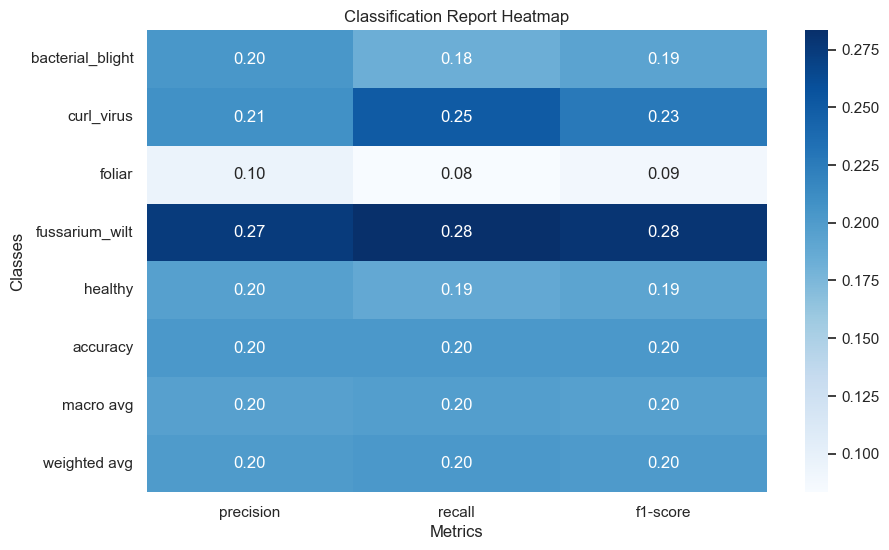

In [17]:
# Generate the classification report
report = classification_report(y_true, y_pred, target_names=class_labels, output_dict=True)

# Convert the report into a DataFrame
df_report = pd.DataFrame(report).transpose()

# Drop support column if you don't want to visualize it
df_report = df_report.drop(columns=['support'])

# Create a heatmap using seaborn
plt.figure(figsize=(10, 6))
sns.heatmap(df_report, annot=True, cmap="Blues", fmt=".2f")

# Add labels and title
plt.title('Classification Report Heatmap')
plt.xlabel('Metrics')
plt.ylabel('Classes')

# Show the plot
plt.show()

# **PLOTTING CNN MODEL LOSS AND ACCURACY**

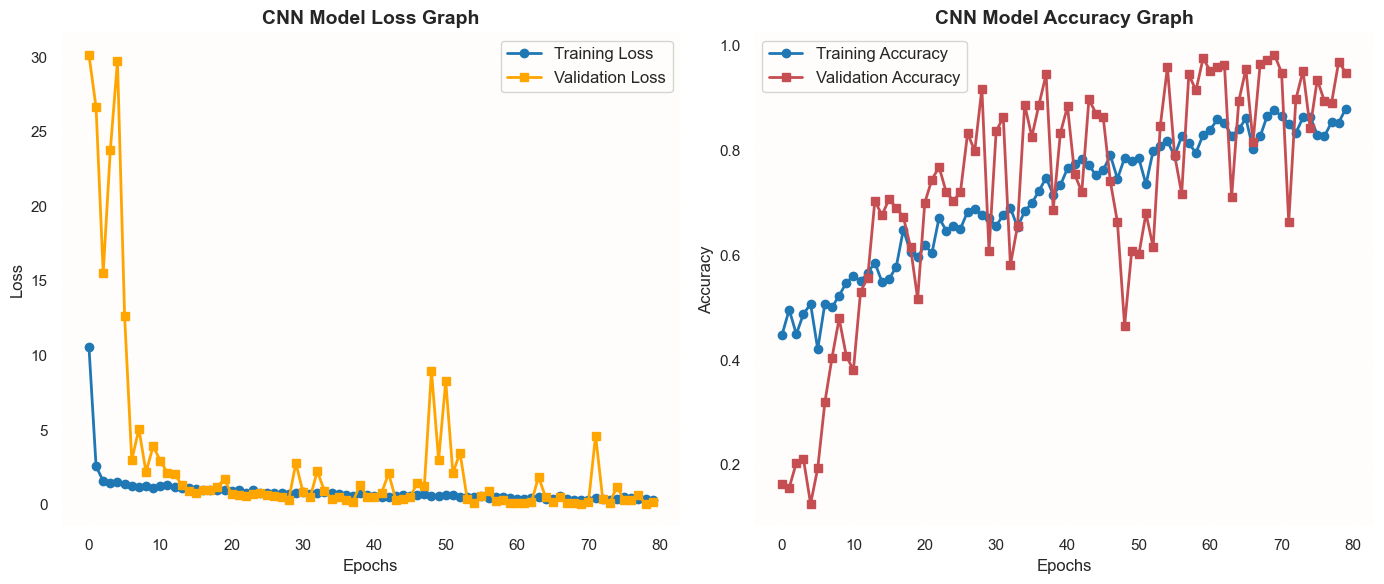

In [19]:
# Set theme with custom background colors
sns.set_theme(rc={'axes.facecolor':'#fffcfc', 'figure.facecolor':'#ffffff'})

# Create subplots
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: Loss Graph
ax[0].plot(history3.history['loss'], label='Training Loss', marker='o', markersize=6, color='#1f77b4', linewidth=2)
ax[0].plot(history3.history['val_loss'], label='Validation Loss', marker='s', markersize=6, color='orange', linewidth=2)
ax[0].set_title('CNN Model Loss Graph', fontsize=14, fontweight='bold')
ax[0].set_xlabel('Epochs', fontsize=12)
ax[0].set_ylabel('Loss', fontsize=12)
ax[0].legend(fontsize=12)
ax[0].grid(True, linestyle='--', alpha=0.6)

# Plot 2: Accuracy Graph
ax[1].plot(history3.history['accuracy'], label='Training Accuracy', marker='o', markersize=6, color='#1f77b4', linewidth=2)
ax[1].plot(history3.history['val_accuracy'], label='Validation Accuracy', marker='s', markersize=6, color='r', linewidth=2)
ax[1].set_title('CNN Model Accuracy Graph', fontsize=14, fontweight='bold')
ax[1].set_xlabel('Epochs', fontsize=12)
ax[1].set_ylabel('Accuracy', fontsize=12)
ax[1].legend(fontsize=12)
ax[1].grid(True, linestyle='--', alpha=0.6)

# Tight layout to avoid overlapping
plt.tight_layout()

#save CNN Model Plotting Image
plt.savefig('D:/thesis Code/Model/CNN_Model_97Acc_80EP.jpg',dpi=500)

# Show plot
plt.show()

# **RESNET_50 & 101 & 152V2**

In [11]:
%%time

#resnet = ResNet152V2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
#resnet = ResNet101(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
resnet = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

CPU times: total: 4.61 s
Wall time: 4.35 s


# **TRAINING RESNET50 MODEL**

In [12]:
%%time

# Fine-tuning: unfreeze last few layers of ResNet
for layer in resnet.layers[-20:]:  # Unfreeze last 20 layers
    layer.trainable = True

# Adding custom layers on top of the model
x = resnet.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.4)(x)  # Increased dropout for better regularization
x = BatchNormalization()(x)
x = Dense(1024, activation='relu')(x)  # Increased neurons to 1024
x = Dropout(0.3)(x)
x = BatchNormalization()(x)

# Predictions layer
predictions = Dense(5, activation='softmax')(x)

# Building model
model = Model(inputs=resnet.input, outputs=predictions)

CPU times: total: 203 ms
Wall time: 204 ms


# **COMPILING RESNET50 MODEL**

In [13]:
%%time

# Compile model with Adam optimizer and a reduced learning rate
optimizer = Adam(learning_rate=1e-4)  # Reduced learning rate
model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

# Adding callbacks
early_stopping = EarlyStopping(monitor='val_accuracy', patience=50, mode='max', restore_best_weights=True, verbose=1)
#reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7, verbose=1)

CPU times: total: 31.2 ms
Wall time: 27.6 ms


# **FITTING RESNET50 MODEL**

In [14]:
history = model.fit(train_generator, 
                    validation_data=validation_generator, 
                    epochs=30, 
                    verbose=1, 
                    class_weight=weight_dict, 
                    callbacks=[early_stopping])
                    #callbacks=[early_stopping, reduce_lr])

Epoch 1/30
35/35 [==============================] - 417s 11s/step - loss: 1.0476 - accuracy: 0.6124 - val_loss: 4.6766 - val_accuracy: 0.1973
Epoch 2/30
35/35 [==============================] - 386s 11s/step - loss: 0.2592 - accuracy: 0.9074 - val_loss: 4.5855 - val_accuracy: 0.2041
Epoch 3/30
35/35 [==============================] - 386s 11s/step - loss: 0.1566 - accuracy: 0.9505 - val_loss: 5.0467 - val_accuracy: 0.2041
Epoch 4/30
35/35 [==============================] - 378s 11s/step - loss: 0.1024 - accuracy: 0.9685 - val_loss: 9.6738 - val_accuracy: 0.2041
Epoch 5/30
35/35 [==============================] - 378s 11s/step - loss: 0.0608 - accuracy: 0.9829 - val_loss: 4.7919 - val_accuracy: 0.2041
Epoch 6/30
35/35 [==============================] - 393s 11s/step - loss: 0.0645 - accuracy: 0.9784 - val_loss: 3.8953 - val_accuracy: 0.2041
Epoch 7/30
35/35 [==============================] - 399s 11s/step - loss: 0.0969 - accuracy: 0.9739 - val_loss: 5.5545 - val_accuracy: 0.2041
Epoch 

# **SAVE RESNET50 MODEL**

In [16]:
#latest saved method using keras extention
#model.save('Cotton_leaf_disease_Resnet.keras')
model.save('D:/thesis Code/Model//CLDD_Resnet50_98ACC_97TS_40EP.keras')

# **LOAD RESNET50 MODEL**

In [18]:
# Load the saved model from the .h5 file
model = load_model('D:/thesis Code/Model/CLDD_Resnet50_98ACC_97TS_40EP.keras')


# **EVALUATING RESNET50 MODEL**

In [19]:
# Evaluate on the validation set
val_loss, val_acc = model.evaluate(validation_generator)
print(f'\033[1mValidation Accuracy: {val_acc * 100:.2f}%\033[0m')

# Evaluate on the test set
test_loss, test_acc = model.evaluate(test_generator)
print(f'\033[1mTest Accuracy: {test_acc * 100:.2f}%\033[0m')

10/10 [==============================] - 34s 3s/step - loss: 0.1698 - accuracy: 0.9864
Validation Accuracy: 98.64%
9/9 [==============================] - 29s 3s/step - loss: 0.1380 - accuracy: 0.9786
Test Accuracy: 97.86%


# **RESNET50 MODEL PREDICTIONS**

In [22]:
# Make predictions on the test set
predictions = model.predict(test_generator)

# Convert predictions to class labels
y_pred = np.argmax(predictions, axis=1)
y_true = test_generator.classes
class_labels = list(test_generator.class_indices.keys())

# Print the predictions
print("Predicted labels:", y_pred)
print("True labels:", y_true)
print("Class labels:", class_labels)



9/9 [==============================] - 31s 3s/step
Predicted labels: [4 0 2 1 2 3 3 3 2 4 1 0 3 3 4 0 0 2 4 2 3 2 1 1 1 3 4 4 3 4 3 0 2 0 4 3 3
 4 1 2 3 4 1 4 3 1 3 0 2 0 4 3 3 1 3 0 4 1 4 2 2 4 2 1 1 3 0 0 4 2 4 3 4 3
 1 0 2 1 0 0 0 0 4 4 0 0 0 1 3 2 0 1 4 0 2 3 1 1 3 4 4 4 2 2 2 0 0 1 0 0 2
 3 4 1 0 1 4 3 2 0 3 4 3 4 3 1 4 3 1 2 1 4 2 4 3 4 2 4 2 3 1 0 3 1 4 1 0 3
 3 1 2 1 2 4 3 2 1 1 0 1 4 4 1 1 2 0 3 2 3 2 0 2 1 1 1 1 2 0 4 2 0 4 0 3 1
 1 3 0 3 1 4 4 1 0 0 1 3 0 1 4 0 0 0 0 1 0 4 3 4 0 4 2 2 1 3 1 2 0 1 3 4 1
 3 3 0 1 4 4 3 1 1 0 2 4 2 3 0 4 3 2 4 3 3 3 0 2 4 2 3 0 3 1 3 1 2 3 2 3 4
 4 3 2 0 1 2 0 0 3 1 0 1 3 0 2 0 4 2 2 2 1 0]
True labels: [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 3 3 3 

# **RESNET50 CLASSIFICATION REPORT**

In [23]:
report = classification_report(y_true,y_pred,target_names=class_labels)
print(report)

                  precision    recall  f1-score   support

bacterial_blight       0.16      0.15      0.15        60
      curl_virus       0.19      0.18      0.19        60
          foliar       0.18      0.19      0.18        48
  fussarium_wilt       0.17      0.17      0.17        60
         healthy       0.13      0.13      0.13        53

        accuracy                           0.16       281
       macro avg       0.16      0.16      0.16       281
    weighted avg       0.16      0.16      0.16       281



# **RESNET50 CLASSIFICATION HEATMAP**

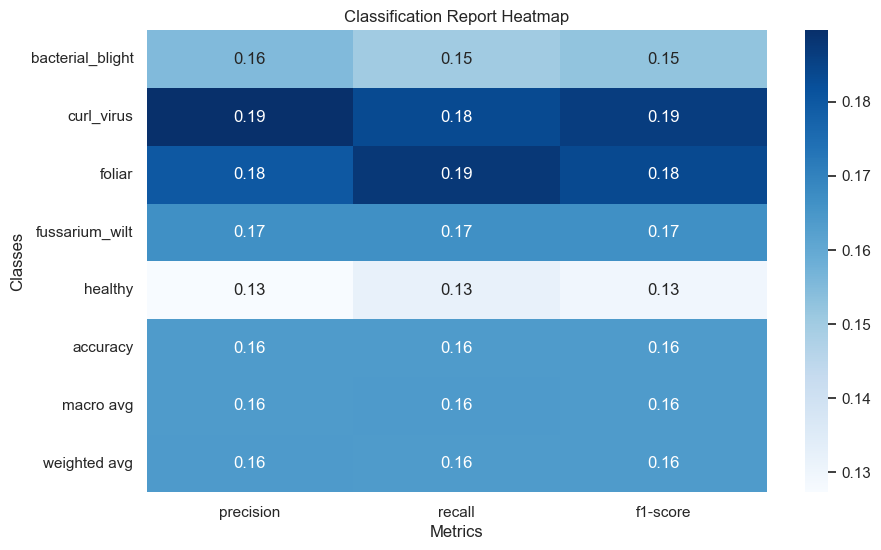

In [24]:
# Generate the classification report
report = classification_report(y_true, y_pred, target_names=class_labels, output_dict=True)

# Convert the report into a DataFrame
df_report = pd.DataFrame(report).transpose()

# Drop support column if you don't want to visualize it
df_report = df_report.drop(columns=['support'])

# Create a heatmap using seaborn
plt.figure(figsize=(10, 6))
sns.heatmap(df_report, annot=True, cmap="Blues", fmt=".2f")

# Add labels and title
plt.title('Classification Report Heatmap')
plt.xlabel('Metrics')
plt.ylabel('Classes')

# Show the plot
plt.show()

# **PLOTTING RESNET50 LOSS AND ACCURACY**

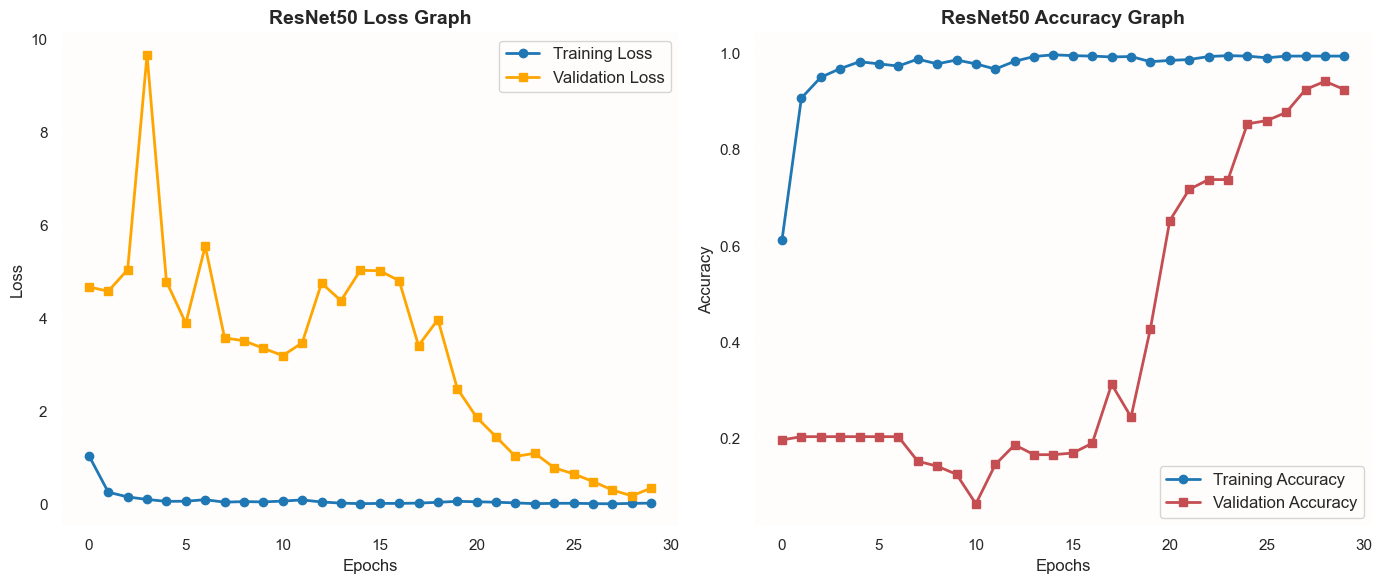

In [19]:
# Set theme with custom background colors
sns.set_theme(rc={'axes.facecolor':'#fffcfc', 'figure.facecolor':'#ffffff'})

# Create subplots
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: Loss Graph
ax[0].plot(history.history['loss'], label='Training Loss', marker='o', markersize=6, color='#1f77b4', linewidth=2)
ax[0].plot(history.history['val_loss'], label='Validation Loss', marker='s', markersize=6, color='orange', linewidth=2)
ax[0].set_title('ResNet50 Loss Graph', fontsize=14, fontweight='bold')
ax[0].set_xlabel('Epochs', fontsize=12)
ax[0].set_ylabel('Loss', fontsize=12)
ax[0].legend(fontsize=12)
ax[0].grid(True, linestyle='--', alpha=0.6)

# Plot 2: Accuracy Graph
ax[1].plot(history.history['accuracy'], label='Training Accuracy', marker='o', markersize=6, color='#1f77b4', linewidth=2)
ax[1].plot(history.history['val_accuracy'], label='Validation Accuracy', marker='s', markersize=6, color='r', linewidth=2)
ax[1].set_title('ResNet50 Accuracy Graph', fontsize=14, fontweight='bold')
ax[1].set_xlabel('Epochs', fontsize=12)
ax[1].set_ylabel('Accuracy', fontsize=12)
ax[1].legend(fontsize=12)
ax[1].grid(True, linestyle='--', alpha=0.6)

# Tight layout to avoid overlapping
plt.tight_layout()

#Save Plot
plt.savefig('D:/thesis Code/Model/ResNet50_Model_97Acc_30EP.jpg',dpi=500)

# Show plot
plt.show()


# **VGG_16**

In [17]:
vgg16 = VGG16(include_top=False, weights='imagenet', input_shape=(224, 224, 3))

# **TRAINING VGG-16 MODEL**

In [20]:
%%time

# Freezing base model
for layer in vgg16.layers:
    layer.trainable = False

# Adding custom layers on top of model
x = vgg16.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.2)(x)
x = BatchNormalization()(x)
x = Flatten()(x)
x = Dense(1024, activation='relu')(x)
x = Dropout(0.2)(x)
x = BatchNormalization()(x)

# Predictions
predictions1 = Dense(5, activation='softmax')(x)

# Building Model
model1 = Model(inputs=vgg16.input, outputs=predictions1)

CPU times: total: 141 ms
Wall time: 172 ms


# **COMPILING VGG16 MODEL**

In [21]:
%%time

model1.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
callbacks = EarlyStopping(monitor='val_accuracy', patience=50, verbose=1,
                            mode='max', restore_best_weights=True)

CPU times: total: 15.6 ms
Wall time: 13.6 ms


# **FITTING VGG16 MODEL**

In [22]:
history1 = model1.fit(train_generator, validation_data=validation_generator, epochs=30, callbacks=[callbacks], verbose=1, class_weight=weight_dict)

Epoch 1/30
35/35 [==============================] - 420s 12s/step - loss: 1.2044 - accuracy: 0.5989 - val_loss: 1.2614 - val_accuracy: 0.4830
Epoch 2/30
35/35 [==============================] - 406s 12s/step - loss: 0.7311 - accuracy: 0.7455 - val_loss: 1.0775 - val_accuracy: 0.5272
Epoch 3/30
35/35 [==============================] - 400s 11s/step - loss: 0.6751 - accuracy: 0.7734 - val_loss: 0.8945 - val_accuracy: 0.6463
Epoch 4/30
35/35 [==============================] - 400s 11s/step - loss: 0.5392 - accuracy: 0.8255 - val_loss: 0.7743 - val_accuracy: 0.6837
Epoch 5/30
35/35 [==============================] - 400s 11s/step - loss: 0.5311 - accuracy: 0.8103 - val_loss: 0.5435 - val_accuracy: 0.8333
Epoch 6/30
35/35 [==============================] - 399s 11s/step - loss: 0.4883 - accuracy: 0.8201 - val_loss: 0.5575 - val_accuracy: 0.7449
Epoch 7/30
35/35 [==============================] - 400s 11s/step - loss: 0.4599 - accuracy: 0.8345 - val_loss: 0.3417 - val_accuracy: 0.8776
Epoch 

# **SAVE VGG-16 MODEL**

In [ ]:
model1.save('D:/thesis Code/Model/cotton_leaf_disease_using_vgg16.H5')

# **LOAD VGG-16 MODEL**

In [25]:
# Load the saved model from the .h5 file
model1 = load_model('D:/thesis Code/Model/cotton_leaf_disease_using_vgg16.H5')


# **EVALUATING VGG16 MODEL**

In [26]:
# Evaluate on the validation set
val_loss, val_acc = model1.evaluate(validation_generator)
print(f'\033[1mValidation Accuracy: {val_acc * 100:.2f}%\033[0m')

# Evaluate on the test set
test_loss, test_acc = model1.evaluate(test_generator)
print(f'\033[1mTest Accuracy: {test_acc * 100:.2f}%\033[0m')

10/10 [==============================] - 89s 9s/step - loss: 0.1236 - accuracy: 0.9626
Validation Accuracy: 96.26%
9/9 [==============================] - 83s 9s/step - loss: 0.2169 - accuracy: 0.9466
Test Accuracy: 94.66%


# **VGG-16 MODEL PREDICTION**

In [27]:
# Make predictions on the test set
predictions = model1.predict(test_generator)

# Convert predictions to class labels
y_pred = np.argmax(predictions, axis=1)
y_true = test_generator.classes
class_labels = list(test_generator.class_indices.keys())

# Print the predictions
print("Predicted labels:", y_pred)
print("True labels:", y_true)
print("Class labels:", class_labels)

9/9 [==============================] - 94s 10s/step
Predicted labels: [1 1 1 3 3 3 0 0 2 2 0 0 1 0 1 1 1 0 0 4 2 4 2 0 1 3 3 1 2 0 3 3 4 0 1 0 4
 2 3 1 3 3 4 3 2 3 4 4 3 4 1 4 1 2 0 1 1 3 2 3 1 2 1 4 4 2 2 1 4 0 4 4 0 3
 1 3 4 3 0 1 3 3 1 3 3 0 3 0 4 4 2 2 2 0 3 2 3 3 1 4 0 0 4 0 3 3 4 0 2 2 2
 2 4 1 4 4 0 0 3 3 2 2 4 2 3 2 3 3 3 1 0 1 1 3 4 4 2 1 3 1 4 4 3 3 2 0 0 0
 2 3 1 2 4 3 4 1 2 1 0 3 3 2 3 2 1 0 4 0 2 0 0 1 4 1 1 1 0 3 2 3 4 1 2 3 2
 0 1 0 4 2 0 0 0 4 2 2 1 0 4 2 3 3 0 0 1 1 1 0 4 4 3 1 4 4 0 3 2 1 4 2 1 1
 3 1 2 4 4 1 4 3 4 4 2 3 1 3 4 3 0 3 1 2 1 1 0 3 0 4 2 2 0 4 0 2 2 4 3 2 3
 0 4 3 0 0 1 3 1 1 2 2 0 0 1 3 4 2 3 3 3 3 0]
True labels: [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 3 3 3

# **VGG-16 CLASSIFICATION REPORT**

In [28]:
report = classification_report(y_true,y_pred,target_names=class_labels)
print(report)

                  precision    recall  f1-score   support

bacterial_blight       0.22      0.20      0.21        60
      curl_virus       0.14      0.13      0.14        60
          foliar       0.21      0.23      0.22        48
  fussarium_wilt       0.12      0.13      0.13        60
         healthy       0.17      0.17      0.17        53

        accuracy                           0.17       281
       macro avg       0.17      0.17      0.17       281
    weighted avg       0.17      0.17      0.17       281



# **VGG_16 CLASSIFICATION HEATMAP**

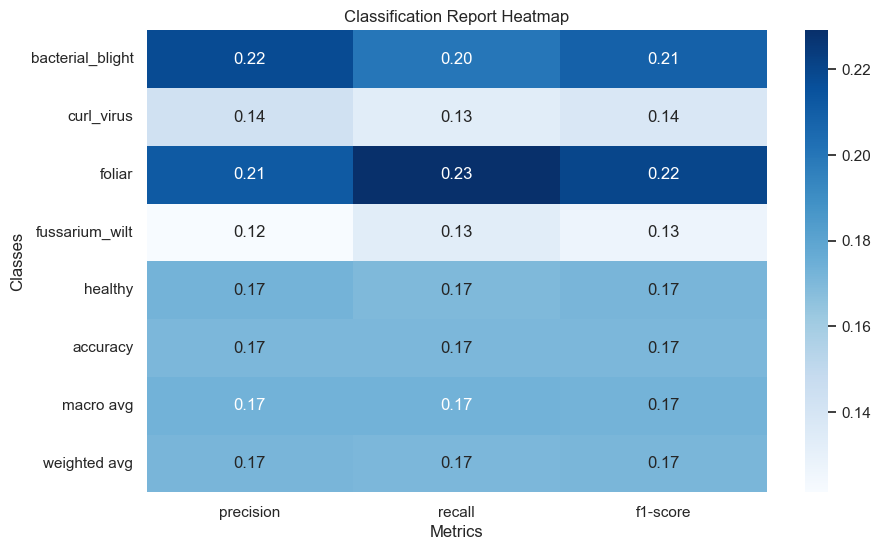

In [29]:
# Generate the classification report
report = classification_report(y_true, y_pred, target_names=class_labels, output_dict=True)

# Convert the report into a DataFrame
df_report = pd.DataFrame(report).transpose()

# Drop support column if you don't want to visualize it
df_report = df_report.drop(columns=['support'])

# Create a heatmap using seaborn
plt.figure(figsize=(10, 6))
sns.heatmap(df_report, annot=True, cmap="Blues", fmt=".2f")

# Add labels and title
plt.title('Classification Report Heatmap')
plt.xlabel('Metrics')
plt.ylabel('Classes')

# Show the plot
plt.show()

# **PLOTTING VGG16 LOSS AND ACCURACY**

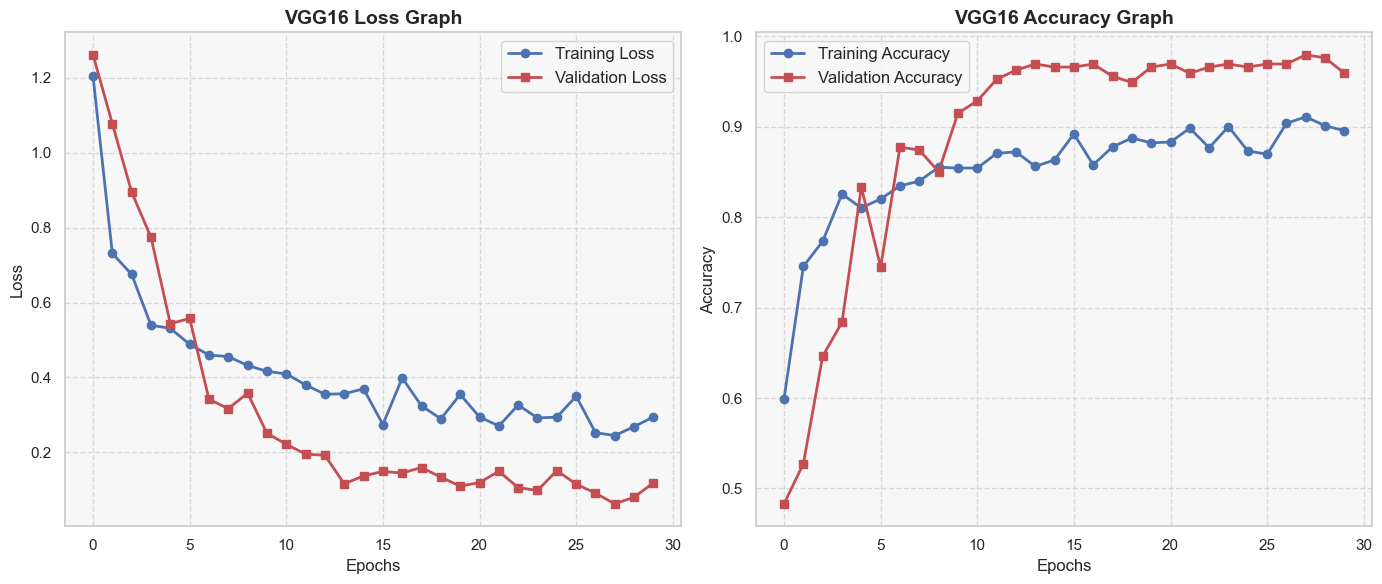

In [26]:
# Create subplots
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: Loss Graph
ax[0].plot(history1.history['loss'], label='Training Loss', marker='o', color='b', linewidth=2)
ax[0].plot(history1.history['val_loss'], label='Validation Loss', marker='s', color='r', linewidth=2)
ax[0].set_title('VGG16 Loss Graph', fontsize=14, fontweight='bold')
ax[0].set_xlabel('Epochs', fontsize=12)
ax[0].set_ylabel('Loss', fontsize=12)
ax[0].legend(fontsize=12)
ax[0].grid(True, linestyle='--', alpha=0.7)

# Plot 2: Accuracy Graph
ax[1].plot(history1.history['accuracy'], label='Training Accuracy', marker='o', color='b', linewidth=2)
ax[1].plot(history1.history['val_accuracy'], label='Validation Accuracy', marker='s', color='r', linewidth=2)
ax[1].set_title('VGG16 Accuracy Graph', fontsize=14, fontweight='bold')
ax[1].set_xlabel('Epochs', fontsize=12)
ax[1].set_ylabel('Accuracy', fontsize=12)
ax[1].legend(fontsize=12)
ax[1].grid(True, linestyle='--', alpha=0.7)

# Adjust layout
plt.tight_layout()

# Save the figure with high DPI
#plt.savefig('D:/thesis Code/Model/VGG16_95Acc_30EP.jpg', dpi=500)

# Show the plot
plt.show()

In [25]:
#model1.save('D:/thesis Code/Model/cotton_leaf_disease_using_vgg16_95ACC_30EP.keras')

# **INCEPTION_V3 Model**

In [29]:
inception = InceptionV3(include_top=False, weights='imagenet', input_shape=(224, 224, 3))

# **TRAINING INCEPTION_V3 MODEL**

In [30]:
%%time

# Freezing base model
for layer in inception.layers:
    layer.trainable = False

# Adding custom layers on top of model
x = inception.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.2)(x)
x = BatchNormalization()(x)
x = Flatten()(x)
x = Dense(512, activation='relu')(x)
x = Dropout(0.2)(x)
x = BatchNormalization()(x)

# Predictions
predictions2 = Dense(5, activation='softmax')(x)

# Building Model
model2 = Model(inputs=inception.input, outputs=predictions2)

CPU times: total: 125 ms
Wall time: 111 ms


# **COMPILING INCEPTION_V3 MODEL**

In [31]:
%%time

model2.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
callbacks = EarlyStopping(monitor='val_accuracy', patience=10, verbose=1,
                            mode='max', restore_best_weights=True)

CPU times: total: 0 ns
Wall time: 9.05 ms


# **FITTING INCEPTION_V3 MODEL**

In [32]:
history2 = model2.fit(train_generator, validation_data=validation_generator, epochs=100, callbacks=[callbacks], verbose=1, class_weight=weight_dict)

Epoch 1/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 111s 3s/step - accuracy: 0.5426 - loss: 1.2871 - val_accuracy: 0.7211 - val_loss: 0.7715
Epoch 2/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 90s 2s/step - accuracy: 0.8300 - loss: 0.4748 - val_accuracy: 0.8878 - val_loss: 0.3084
Epoch 3/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 90s 2s/step - accuracy: 0.8722 - loss: 0.3817 - val_accuracy: 0.9184 - val_loss: 0.2047
Epoch 4/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 90s 2s/step - accuracy: 0.8756 - loss: 0.3428 - val_accuracy: 0.9422 - val_loss: 0.1650
Epoch 5/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 88s 2s/step - accuracy: 0.8688 - loss: 0.3477 - val_accuracy: 0.9592 - val_loss: 0.1160
Epoch 6/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 89s 2s/step - accuracy: 0.8868 - loss: 0.3104 - val_accuracy: 0.9490 - val_loss: 0.1293
Epoch 7/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 90s 2s/step - accuracy: 0.8742 - loss: 0.3269 - val_accuracy: 0.9728 - val_loss: 0.0993
Epoch 8/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 87s 2s/step - accuracy: 0.9211 - loss: 0.2534 - val_accuracy: 0.9592 - 

# **SAVE INCEPTION-V3 MODEL**

In [ ]:
model2.save('D:/thesis Code/Model/cotton_leaf_disease_using_inceptionV3.H5')

# **INCEPTION_V3 MODEL LOAD**

In [21]:
# Load the Inception_V3 saved model from the .h5 file
model2 = load_model('D:/thesis Code/Model/cotton_leaf_disease_using_inceptionV3.H5')

# **INCEPTION_V3 MODEL PREDICTION**

In [31]:
# Make predictions on the test set
predictions = model2.predict(test_generator)

# Convert predictions to class labels
y_pred = np.argmax(predictions, axis=1)
y_true = test_generator.classes
class_labels = list(test_generator.class_indices.keys())

# Print the predictions
print("Predicted labels:", y_pred)
print("True labels:", y_true)
print("Class labels:", class_labels)

9/9 [==============================] - 26s 2s/step
Predicted labels: [0 4 0 1 1 4 0 3 1 2 3 1 2 1 1 1 0 3 2 0 0 3 3 2 1 3 2 4 3 4 4 2 4 3 2 3 1
 0 3 2 4 4 4 1 0 0 0 3 4 2 0 3 2 0 4 0 2 0 0 0 4 3 3 0 4 0 0 3 4 0 1 0 4 4
 2 3 1 1 4 0 3 1 0 3 3 2 3 1 4 2 2 4 1 2 3 3 3 4 3 0 2 1 2 2 4 0 3 1 2 3 2
 1 2 2 4 3 4 2 3 4 1 0 4 2 1 0 2 3 3 4 3 3 4 1 0 4 3 1 0 1 4 0 4 4 2 1 1 1
 0 1 0 1 3 4 1 4 3 1 0 4 0 4 1 4 1 0 3 2 3 3 3 1 3 2 3 4 0 4 3 1 1 0 4 0 1
 4 4 3 0 0 2 1 1 1 0 4 4 1 3 1 2 0 3 0 3 2 1 3 0 2 0 3 3 1 1 1 0 4 1 3 0 2
 1 2 3 1 3 0 1 1 2 1 3 2 2 0 2 2 3 2 4 1 3 4 0 1 0 2 4 2 0 3 2 1 0 0 2 1 2
 0 1 2 3 2 1 0 4 2 0 2 1 4 0 3 1 4 3 3 0 3 0]
True labels: [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 3 3 3 

# **INCEPTION_V3 CLASSIFICATION REPORT**

In [32]:
report = classification_report(y_true,y_pred,target_names=class_labels)
print(report)

                  precision    recall  f1-score   support

bacterial_blight       0.27      0.27      0.27        60
      curl_virus       0.15      0.15      0.15        60
          foliar       0.08      0.08      0.08        48
  fussarium_wilt       0.26      0.27      0.26        60
         healthy       0.12      0.11      0.12        53

        accuracy                           0.18       281
       macro avg       0.18      0.18      0.18       281
    weighted avg       0.18      0.18      0.18       281



# **INCEPTION_V3 CLASSIFICATION HEATMAP**

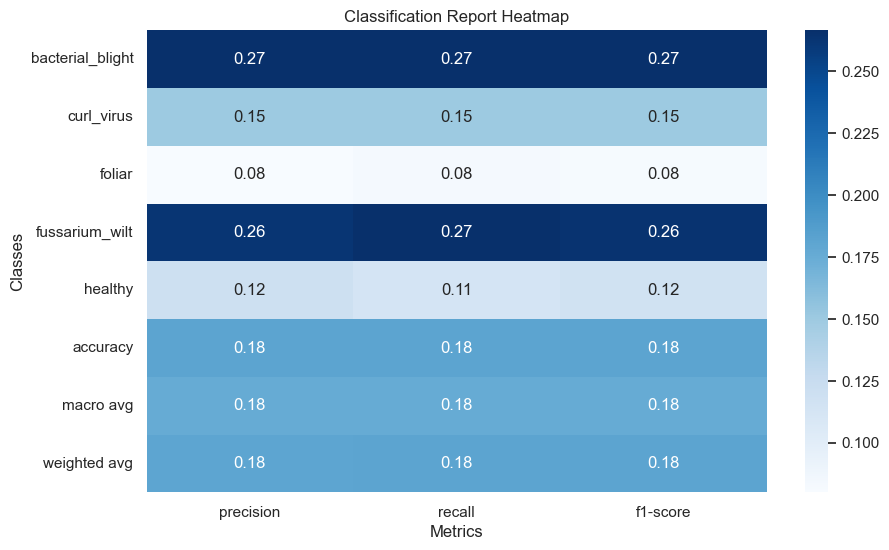

In [33]:
# Generate the classification report
report = classification_report(y_true, y_pred, target_names=class_labels, output_dict=True)

# Convert the report into a DataFrame
df_report = pd.DataFrame(report).transpose()

# Drop support column if you don't want to visualize it
df_report = df_report.drop(columns=['support'])

# Create a heatmap using seaborn
plt.figure(figsize=(10, 6))
sns.heatmap(df_report, annot=True, cmap="Blues", fmt=".2f")

# Add labels and title
plt.title('Classification Report Heatmap')
plt.xlabel('Metrics')
plt.ylabel('Classes')

# Show the plot
plt.show()

# **EVALUATING INCEPTION_V3 MODEL**

In [22]:
# Evaluate on the Training set
loss, train_acc = model2.evaluate(train_generator)
print(f'\033[1m Training Accuracy: {train_acc * 100:.2f}%\033[0m')

# Evaluate on the validation set
val_loss, val_acc = model2.evaluate(validation_generator)
print(f'\033[1mValidation Accuracy: {val_acc * 100:.2f}%\033[0m')

# Evaluate on the test set
test_loss, test_acc = model2.evaluate(test_generator)
print(f'\033[1mTest Accuracy: {test_acc * 100:.2f}%\033[0m')

35/35 [==============================] - 87s 2s/step - loss: 0.0915 - accuracy: 0.9640
 Training Accuracy: 96.40%
10/10 [==============================] - 22s 2s/step - loss: 0.0317 - accuracy: 0.9898
Validation Accuracy: 98.98%
9/9 [==============================] - 21s 2s/step - loss: 0.0881 - accuracy: 0.9715
Test Accuracy: 97.15%


# **1-PLOTTING INCEPTION_V3 LOSS AND ACCURACY**

TypeError: 'History' object is not subscriptable

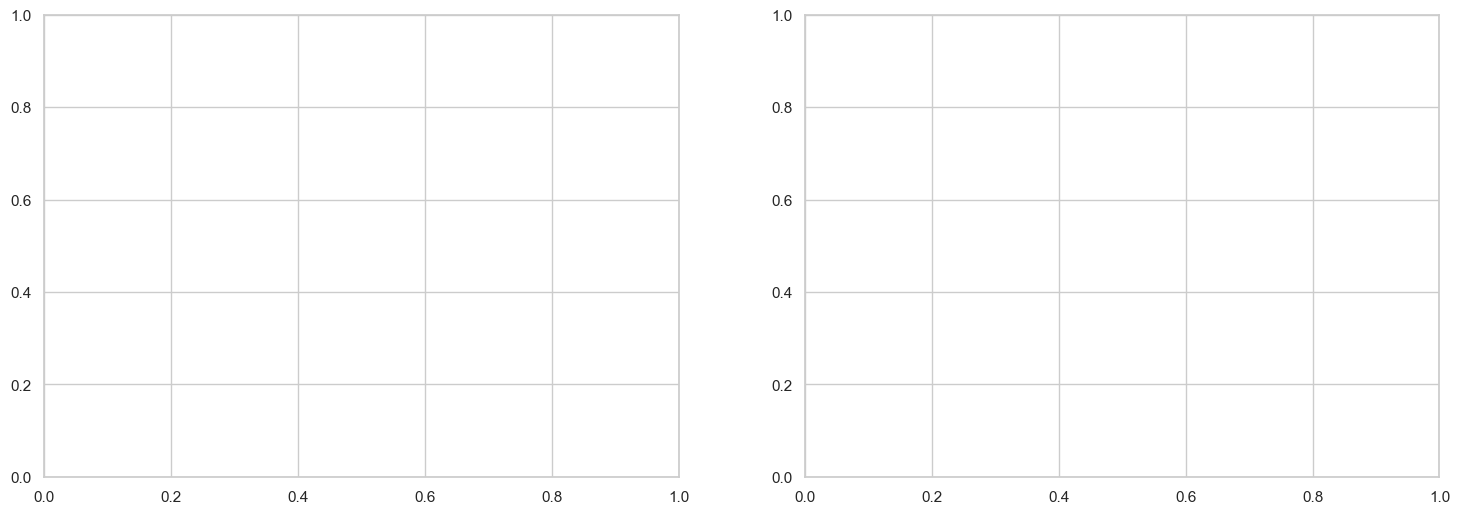

In [24]:
# Set a Seaborn theme for better visuals
sns.set(style="whitegrid")

# Creating the subplots
fig, ax = plt.subplots(1, 2, figsize=(18, 6))

# Plot 1: Training vs Validation Loss
ax[0].plot(history2.history['loss'], label='Train Loss', marker='o', markersize=6, color='#2ca02c', linewidth=2)
ax[0].plot(history2.history['val_loss'], label='Validation Loss', marker='s', markersize=6, color='#d62728', linewidth=2)
ax[0].set_title('Inception_V3 Loss Graph', fontsize=14, fontweight='bold')
ax[0].set_xlabel('Epochs', fontsize=12)
ax[0].set_ylabel('Loss', fontsize=12)
ax[0].legend(loc='upper right', fontsize=12, fancybox=True, shadow=True)
ax[0].grid(True, linestyle='--', alpha=0.7)

# Plot 2: Zoomed in Accuracy Comparison
ax[1].plot(history2.history['accuracy'], label='Train Accuracy', marker='o', markersize=6, color='#9467bd', linewidth=2)
ax[1].plot(history2.history['val_accuracy'], label='Validation Accuracy', marker='s', markersize=6, color='#8c564b', linewidth=2)
ax[1].set_title('Inception_V3 Accuracy Graph', fontsize=14, fontweight='bold')
ax[1].set_xlabel('Epochs', fontsize=12)
ax[1].set_ylabel('Accuracy', fontsize=12)
ax[1].legend(loc='lower right', fontsize=12, fancybox=True, shadow=True)
ax[1].grid(True, linestyle='--', alpha=0.7)

# Tight layout for better spacing
plt.tight_layout()

#save image into jpg format
#plt.savefig('D:/thesis Code/Model/2_Inceptionv3_97Acc_35EP.jpg',dpi=500)

# Show the plot
plt.show()

# **2-PLOTTING INCEPTION_V3 LOSS AND ACCURACY**

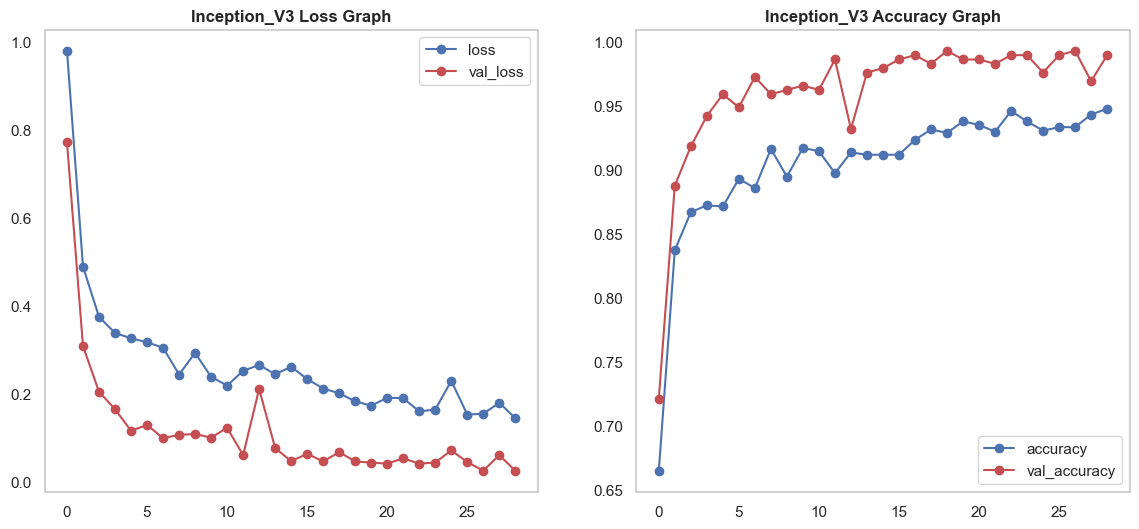

In [49]:
fig,ax = plt.subplots(1,2,figsize=(14,6))

ax[0].plot(history2.history['loss'],label='loss',marker='o', color='b')
ax[0].plot(history2.history['val_loss'],label='val_loss',marker='o', color='r')
ax[0].set_title('Inception_V3 Loss Graph',fontweight='bold')
ax[0].legend()
ax[0].grid(False)

ax[1].plot(history2.history['accuracy'],label='accuracy',marker='o', color='b')
ax[1].plot(history2.history['val_accuracy'],label='val_accuracy',marker='o', color='r')
ax[1].set_title('Inception_V3 Accuracy Graph',fontweight='bold')
ax[1].legend()
ax[1].grid(False)

#plt.savefig('D:/thesis Code/Model/Inceptionv3_97Acc_35EP.jpg',dpi=500)

plt.show()

# **SAVE INCEPTION-V3 MODEL**

In [54]:
model2.save('C:/Users/Lenovo/CLDD/thesis Code/Model/cotton_leaf_disease_using_inceptionV3_Latest.keras')

# **Result Prediction**

In [ ]:
if len(y_pred) == 0:
    print("No predictions were made.")
else:
    # Iterate over each prediction
    for i in range(len(y_pred)):
        if y_pred[i] == 0:
            preds = "The leaf is bacterial blight"
        elif y_pred[i] == 1:
            preds = "The leaf is curl virus"
        elif y_pred[i] == 2:
            preds = "The leaf is fussarium wilt"
        else:
            preds = "The leaf is healthy"

        print(f"Prediction {i+1}: {preds}")